In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data=pd.read_csv("pokemon_data.csv")
data

,dexnum,name,generation,type1,type2,species,height,weight,ability1,ability2,...,catch_rate,base_friendship,base_exp,growth_rate,egg_group1,egg_group2,percent_male,percent_female,egg_cycles,special_group
0,1,Bulbasaur,1,Grass,Poison,Seed Pokémon,0.7,6.9,Overgrow,Chlorophyll,...,45,50,64,Medium Slow,Grass,Monster,87.5,12.5,20,Ordinary
1,2,Ivysaur,1,Grass,Poison,Seed Pokémon,1.0,13.0,Overgrow,Chlorophyll,...,45,50,142,Medium Slow,Grass,Monster,87.5,12.5,20,Ordinary
2,3,Venusaur,1,Grass,Poison,Seed Pokémon,2.0,100.0,Overgrow,Chlorophyll,...,45,50,236,Medium Slow,Grass,Monster,87.5,12.5,20,Ordinary
3,4,Charmander,1,Fire,NaN,Lizard Pokémon,0.6,8.5,Blaze,Solar Power,...,45,50,62,Medium Slow,Dragon,Monster,87.5,12.5,20,Ordinary
4,5,Charmeleon,1,Fire,NaN,Flame Pokémon,1.1,19.0,Blaze,Solar Power,...,45,50,142,Medium Slow,Dragon,Monster,87.5,12.5,20,Ordinary
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,1021,Raging Bolt,9,Electric,Dragon,Paradox Pokémon,5.2,480.0,Protosynthesis,NaN,...,10,—,—,Slow,Undiscovered,NaN,NaN,NaN,—,Ancient Paradox
1021,1022,Iron Boulder,9,Rock,Psychic,Paradox Pokémon,1.5,162.5,Quark Drive,NaN,...,10,—,—,Slow,Undiscovered,NaN,NaN,NaN,—,Future Paradox
1022,1023,Iron Crown,9,Steel,Psychic,Paradox Pokémon,1.6,156.0,Quark Drive,NaN,...,10,—,—,Slow,Undiscovered,NaN,NaN,NaN,—,Future Paradox
1023,1024,Terapagos,9,Normal,NaN,Tera Pokémon,0.2,6.5,Tera Shift,NaN,...,255,—,—,Slow,Undiscovered,NaN,50.0,50.0,—,Legendary


1. Distribution of HP
Plot a histogram of the hp column using Seaborn or Matplotlib.
Add a reasonable number of bins (e.g., 10–20).
Task: What range of HP values seems most common?


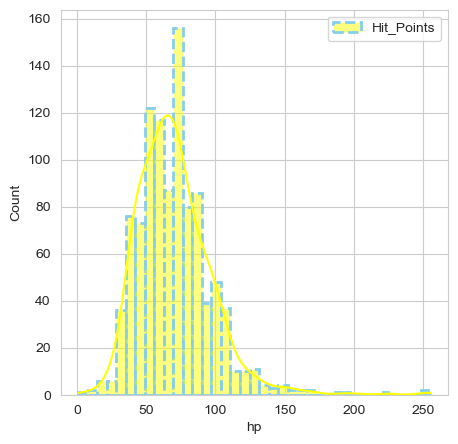

In [13]:
plt.figure(figsize=(5,5))
sns.histplot(data["hp"],
             color="yellow",edgecolor="skyblue",
             linewidth=2,linestyle="--",label="Hit_Points",kde=True)
sns.set_style("whitegrid")
plt.legend()
plt.show()

most common HP values range=50-80

2. Distribution of Speed
Plot a histogram of the speed column.
Task: Are there more slow Pokémon or fast Pokémon? (Look at where most bars are concentrated.)


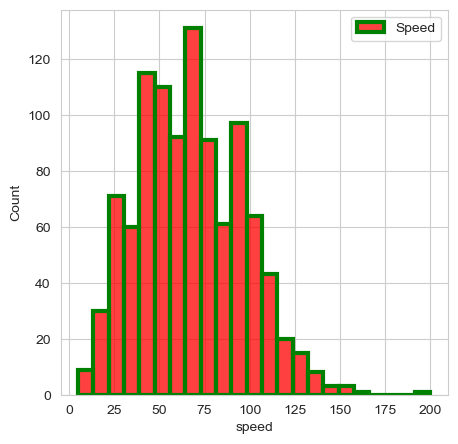

In [19]:
plt.figure(figsize=(5,5))
sns.histplot(data["speed"],
             color="red",
             edgecolor="green",linewidth=3,
             label="Speed")
plt.legend()
plt.show()

there are more slow pokemons than fast pokemons

3. Count of Pokémon by Primary Type (type1)
Create a countplot of type1 to see how many Pokémon exist of each primary type.
Task: Which primary type has the most Pokémon? Which types are relatively rare?


<Axes: xlabel='type1', ylabel='count'>

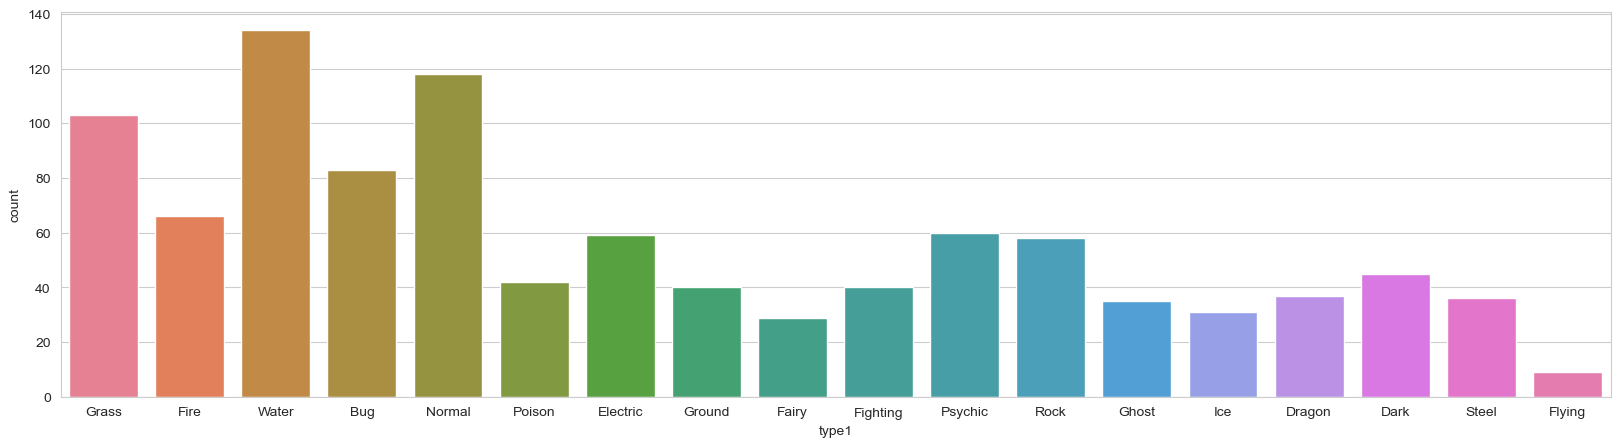

In [26]:
plt.figure(figsize=(20,5))
sns.countplot(data=data,x=data["type1"],hue="type1",label="type1")

water type has the most pokemon and flying,fairy,ice,ghost types are relatively rare

4. Average Attack by Primary Type
Group the data by type1 and calculate the mean attack for each type.
Plot this as a bar plot (type on x-axis, average attack on y-axis).
Task: Which type1 has the highest average attack?


In [32]:
df=data.groupby("type1")["attack"].agg("mean").sort_values(ascending=False)
print(df)

type1
Fighting    102.700000
Dragon       98.972973
Ground       93.400000
Dark         88.000000
Steel        88.000000
Rock         86.465517
Fire         82.606061
Flying       79.888889
Poison       75.547619
Ice          74.419355
Normal       74.381356
Grass        74.349515
Electric     72.966102
Water        72.343284
Ghost        68.600000
Bug          67.554217
Fairy        66.827586
Psychic      63.000000
Name: attack, dtype: float64


Text(0, 0.5, 'average_attack')

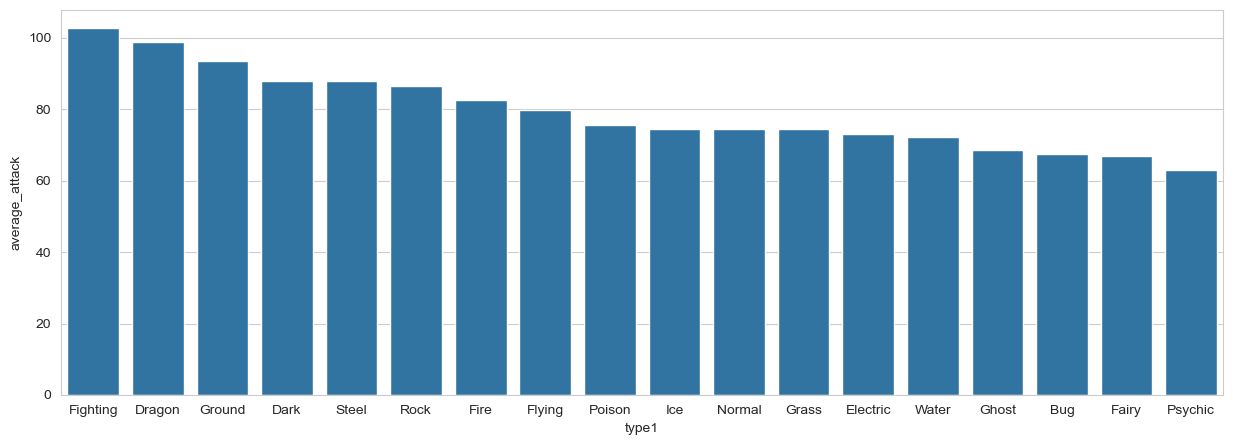

In [39]:
plt.figure(figsize=(15,5))
sns.barplot(x=df.index,y=df.values)
plt.xlabel("type1")
plt.ylabel("average_attack")

fighting type Pokemon has the highest average attack

5. Speed by Primary Type (Boxplot)
Draw a boxplot with:
x-axis: type1
y-axis: speed
Task: Which type1 tends to have the fastest Pokémon (higher median)? Which types show a large spread in Speed? (Hint: You may rotate x-axis labels for readability.)


Text(0.5, 1.0, 'speed by primary type')

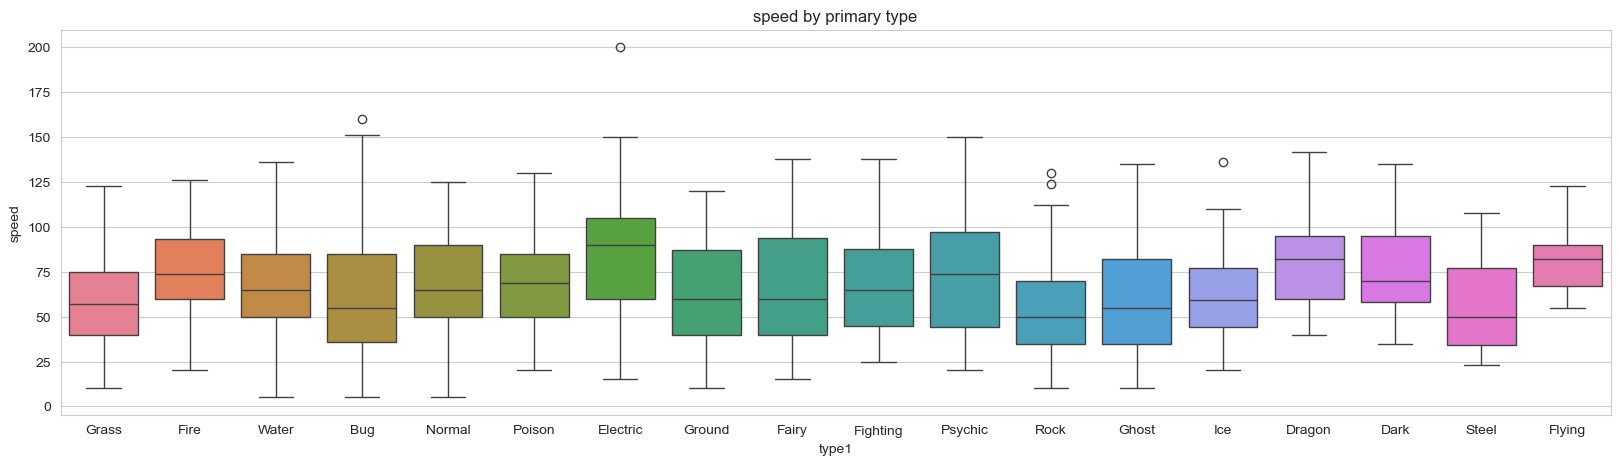

In [44]:
plt.figure(figsize=(20,5))
sns.boxplot(data=data,x="type1",y="speed",hue="type1")
plt.title("speed by primary type")

In [ ]:
electric type have the fastest pokemon

6. Comparison Across Generations: Count of Pokémon
Use a countplot (or bar plot) to show the number of Pokémon in each generation.
Task: Which Generation has the most Pokémon in this dataset?

<Axes: xlabel='generation', ylabel='count'>

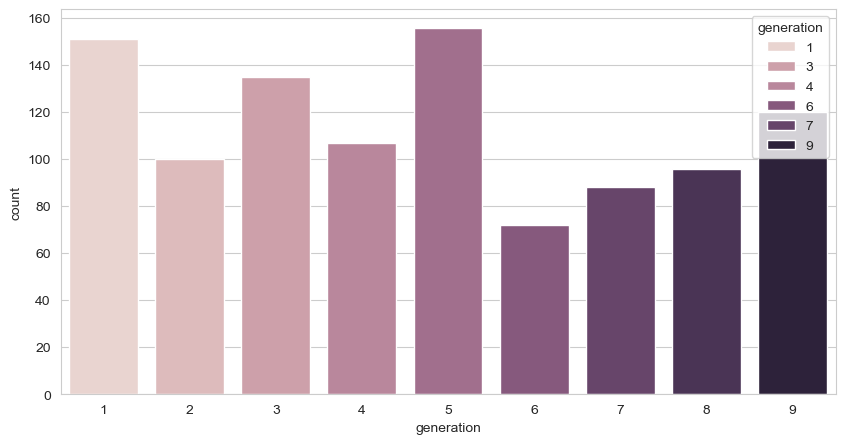

In [51]:
plt.figure(figsize=(10,5))
sns.countplot(data=data,x="generation",hue="generation")

5th generation has the most pokemons

7. Average Total Stats by Generation
Group by generation and compute the average of total.
Plot a bar plot of generation vs average total.
Task: Do later generations seem to have higher or lower total stats on average?


generation
1    407.642384
2    407.180000
3    403.725926
4    445.570093
5    425.756410
6    429.305556
7    449.409091
8    439.218750
9    457.391667
Name: total, dtype: float64


Text(0, 0.5, 'avg_total')

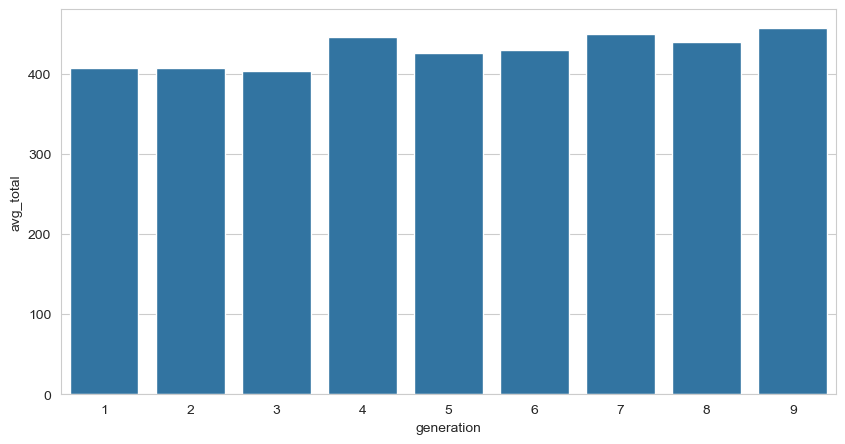

In [58]:
df=data.groupby("generation")["total"].mean()
print(df)
plt.figure(figsize=(10,5))
sns.barplot(x=df.index,y=df.values)
plt.xlabel("generation")
plt.ylabel("avg_total")


later generationd seems to have higher total stats

8. Relationship Between Attack and Defense
Make a scatter plot:
x-axis: attack
y-axis: defense.
Task: Is there any visible relationship between attack and defense (e.g., do high-attack Pokémon also tend to have high defense)?


<Axes: xlabel='attack', ylabel='defense'>

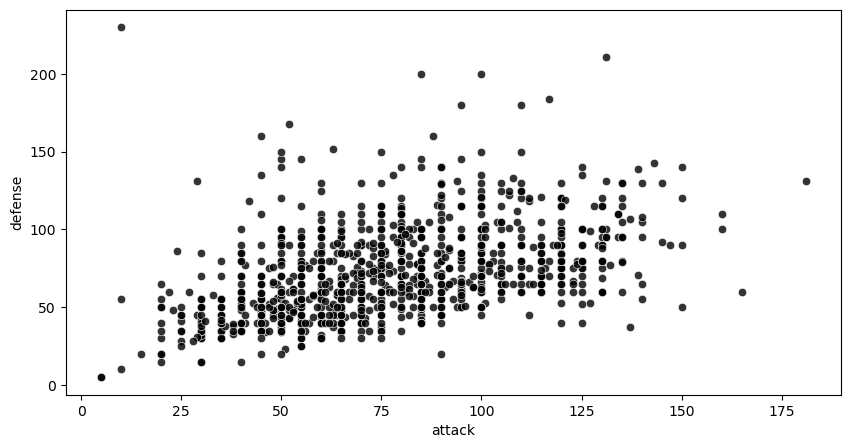

In [10]:
plt.figure(figsize=(10,5))
sns.scatterplot(data=data,x="attack",y="defense",alpha=0.8,color="black")

There’s no strong relationship.
The scatter is wide, messy, and shows only a weak upward trend at best.

9. Relationship Between Speed and Total
Create a scatter plot of:
x-axis: speed
y-axis: total.
Task: Do faster Pokémon generally have higher total stats, or is it spread out?


<Axes: xlabel='speed', ylabel='total'>

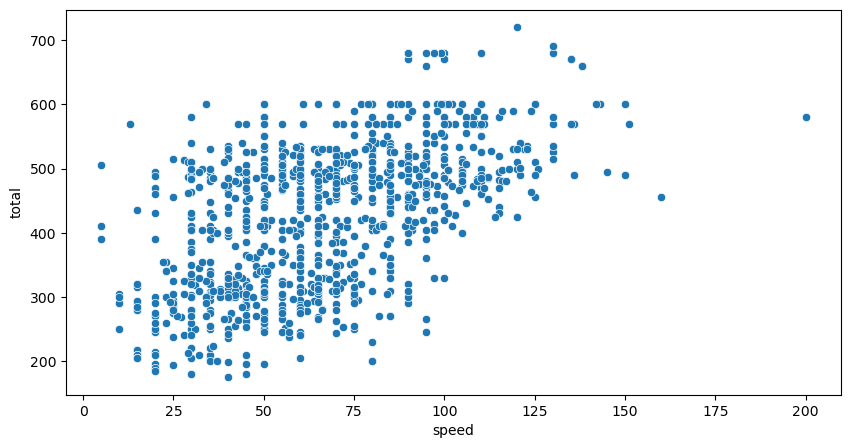

In [11]:
plt.figure(figsize=(10,5))
sns.scatterplot(data=data,x="speed",y="total")

Not really.
The cloud is wide and scattered, not forming a clean upward trend.

10. Heatmap of Correlations Between Stats
Select only numeric stat columns: ['hp', 'attack', 'defense', 'sp_atk', 'sp_def', 'speed', 'total'].
Compute their correlation matrix using df[cols].corr().
Plot a heatmap of this correlation matrix using sns.heatmap (with annot=True if possible).
Task: Which pair of stats seems most strongly positively correlated? Is any stat weakly related to the others?


In [13]:
data[['hp', 'attack', 'defense', 'sp_atk', 'sp_def', 'speed', 'total']].corr()

,hp,attack,defense,sp_atk,sp_def,speed,total
hp,1.000000,0.476141,0.299013,0.359616,0.369087,0.179877,0.667127
attack,0.476141,1.000000,0.465565,0.281880,0.226126,0.351055,0.714396
defense,0.299013,0.465565,1.000000,0.210107,0.503281,0.008047,0.629466
sp_atk,0.359616,0.281880,0.210107,1.000000,0.493034,0.423150,0.701154
sp_def,0.369087,0.226126,0.503281,0.493034,1.000000,0.214105,0.697998
speed,0.179877,0.351055,0.008047,0.423150,0.214105,1.000000,0.553797
total,0.667127,0.714396,0.629466,0.701154,0.697998,0.553797,1.000000


<Axes: >

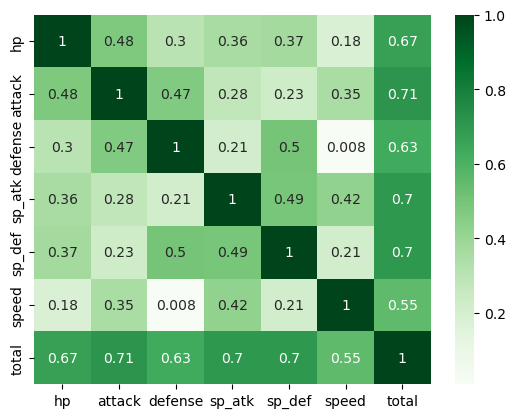

In [15]:
sns.heatmap(data[['hp', 'attack', 'defense', 'sp_atk', 'sp_def', 'speed', 'total']].corr(),annot=True,cmap="Greens")